# Análise Estrutural da Malha Viária de Salo, Finlândia

**Disciplina:** DCA3702 – Estrutura de Dados II  
**Região de estudo:** Cidade de Salo – Finlândia  
**Ferramentas:** OSMnx · NetworkX · Gephi 0.11.2

---

## Justificativa da Região de Estudo

**Salo** é uma cidade de porte médio localizada na região de **Finland Proper (Varsinais-Suomi)**, a sudoeste da Finlândia, às margens do rio Uskelanjoki. Conhecida como antiga sede da Nokia, a cidade concentra cerca de 55.000 habitantes e integra os municípios da Grande Área de Turku.

No ano de 2016 realisei um intercâmbio para essa região e achei interessante usá-la como modelo para este projeto, tendo em vista que se trata de uma região consideravelmente pequena e como morei na região por um período de 1 ano possuo certa familiaridade com a região.

Espera-se que a análise revele alta concentração de betweenness nos corredores centrais e nas conexões com a E18, núcleos k-core bem definidos na área central, e closeness elevada nas interseções próximas ao centro comercial e à estação ferroviária.

---
## Etapa 0 – Instalação e Importações

In [1]:
# Instalação das dependências necessárias
!pip install osmnx networkx pandas matplotlib numpy seaborn --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 2.1 MB/s eta 0:00:00


In [2]:
import osmnx as ox
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np
import seaborn as sns
import warnings
from collections import Counter

warnings.filterwarnings('ignore')

# Configurações gerais
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 10)
ox.settings.log_console = False
ox.settings.use_cache = True

print(f"✅ Bibliotecas carregadas com sucesso!")
print(f"   OSMnx version:    {ox.__version__}")
print(f"   NetworkX version: {nx.__version__}")
print(f"   Seaborn version:  {sns.__version__}")

✅ Bibliotecas carregadas com sucesso!
   OSMnx version:    2.1.0
   NetworkX version: 3.6.1
   Seaborn version:  0.13.2


---
## Etapa 1 – Construção do Grafo com OSMnx

Baixamos a rede viária completa de **Salo** usando `network_type="drive"`, que retorna apenas vias transitáveis por veículos motorizados. O resultado é um **MultiDiGraph** georreferenciado, onde nós representam interseções e arestas representam segmentos de via.

In [3]:
# Definindo a região de estudo
place = "Salo, Finland"

print(f"📥 Baixando rede viária de: {place}")
print("   Aguarde... isso pode levar alguns minutos na primeira execução.")

# Baixar o grafo viário dirigido
G = ox.graph_from_place(place, network_type="drive")

print("\n" + "="*55)
print("ESTATÍSTICAS DO GRAFO ORIGINAL (MultiDiGraph)")
print("="*55)
print(f"  Tipo do grafo:                  {type(G).__name__}")
print(f"  Número de nós (interseções):    {G.number_of_nodes():,}")
print(f"  Número de arestas (segmentos):  {G.number_of_edges():,}")
print(f"  É direcionado?                  {G.is_directed()}")

📥 Baixando rede viária de: Salo, Finland
   Aguarde... isso pode levar alguns minutos na primeira execução.

ESTATÍSTICAS DO GRAFO ORIGINAL (MultiDiGraph)
  Tipo do grafo:                  MultiDiGraph
  Número de nós (interseções):    4,871
  Número de arestas (segmentos):  11,069
  É direcionado?                  True


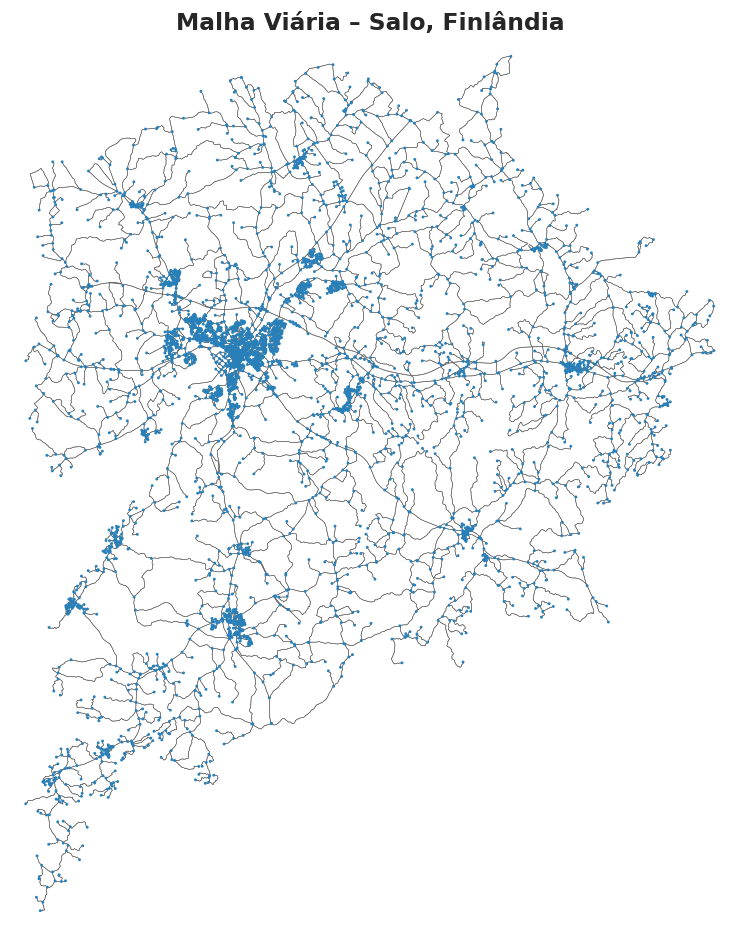

📸 Figura salva: fig01_malha_viaria.png


In [4]:
# Visualização geográfica inicial
fig, ax = ox.plot_graph(
    G,
    node_size=3,
    node_color='#2980B9',
    edge_color='#555555',
    edge_linewidth=0.3,
    bgcolor='white',
    show=False,
    close=False
)
ax.set_title("Malha Viária – Salo, Finlândia", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("fig01_malha_viaria.png", bbox_inches='tight', dpi=150)
plt.show()
print("📸 Figura salva: fig01_malha_viaria.png")

---
## Etapa 2 – Preparação dos Grafos para Análise

Para as análises de centralidade, convertemos o grafo original em representações complementares:

| Variável | Tipo | Uso |
|---|---|---|
| `G` | MultiDiGraph (OSMnx) | Grafo original dirigido com geometria |
| `G_undirected` | MultiGraph | Visualizações com `ox.plot_graph` |
| `G_simple` | Graph (NetworkX simples) | Cálculo de métricas (core, eigenvector) |
| `G_connected` | Graph (maior componente) | Closeness centrality (requer conectividade) |

In [5]:
# 1. Converter para não direcionado (mantém MultiGraph para ox.plot_graph)
G_undirected = ox.convert.to_undirected(G)

# 2. Converter para grafo simples (sem arestas paralelas, sem self-loops)
G_simple = nx.Graph(G_undirected)
G_simple.remove_edges_from(nx.selfloop_edges(G_simple))

# 3. Remover nós isolados do grafo simples
isolados = list(nx.isolates(G_simple))
G_simple.remove_nodes_from(isolados)

# 4. Identificar Maior Componente Conectada (LCC) — necessária para Closeness
largest_cc = max(nx.connected_components(G_simple), key=len)
G_connected = G_simple.subgraph(largest_cc).copy()

# 5. Grau dos nós (baseado no G_undirected para incluir multi-arestas)
degree_dict = dict(G_undirected.degree())

print("✅ Grafos preparados com sucesso!")
print(f"\n  G_undirected : {G_undirected.number_of_nodes():,} nós | {G_undirected.number_of_edges():,} arestas")
print(f"  G_simple     : {G_simple.number_of_nodes():,} nós | {G_simple.number_of_edges():,} arestas")
print(f"  G_connected  : {G_connected.number_of_nodes():,} nós | {G_connected.number_of_edges():,} arestas")
print(f"  Nós isolados removidos: {len(isolados)}")

✅ Grafos preparados com sucesso!

  G_undirected : 4,871 nós | 5,727 arestas
  G_simple     : 4,871 nós | 5,624 arestas
  G_connected  : 4,871 nós | 5,624 arestas
  Nós isolados removidos: 0


---
## Etapa 3 – Métricas de Centralidade

### 3.1 Grau dos Nós e Distribuição de Grau

O **grau** de um nó em uma rede viária corresponde ao número de segmentos de rua conectados a uma interseção. Espera-se predominância de nós com grau 3 (cruzamentos em T) no centro histórico orgânico e grau 4 (cruzamentos em +) nas expansões planejadas do século XX. Nós de grau 1 indicam becos ou vias sem saída, frequentes nas áreas residenciais suburbanas.

In [6]:
# Dados de grau
degrees = list(degree_dict.values())
nx.set_node_attributes(G_undirected, degree_dict, 'grau')

# Estatísticas descritivas
print("="*50)
print("ANÁLISE DE GRAU DOS NÓS")
print("="*50)
print(f"  Grau médio:        {np.mean(degrees):.2f}")
print(f"  Grau mediano:      {np.median(degrees):.2f}")
print(f"  Grau máximo:       {max(degrees)}")
print(f"  Grau mínimo:       {min(degrees)}")
print(f"  Desvio padrão:     {np.std(degrees):.2f}")

top_degree = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)[:10]
print("\n🏆 TOP 10 HUBS (nós com maior grau):")
print(f"  {'Rank':<5} {'Node ID':<15} {'Grau':<10}")
print(f"  {'-'*30}")
for i, (node, deg) in enumerate(top_degree, 1):
    print(f"  {i:<5} {node:<15} {deg:<10}")

ANÁLISE DE GRAU DOS NÓS
  Grau médio:        2.35
  Grau mediano:      3.00
  Grau máximo:       5
  Grau mínimo:       1
  Desvio padrão:     1.03

🏆 TOP 10 HUBS (nós com maior grau):
  Rank  Node ID         Grau      
  ------------------------------
  1     112044055       5         
  2     693292          4         
  3     693360          4         
  4     693404          4         
  5     693477          4         
  6     60039005        4         
  7     60039104        4         
  8     100155120       4         
  9     100155178       4         
  10    100155196       4         


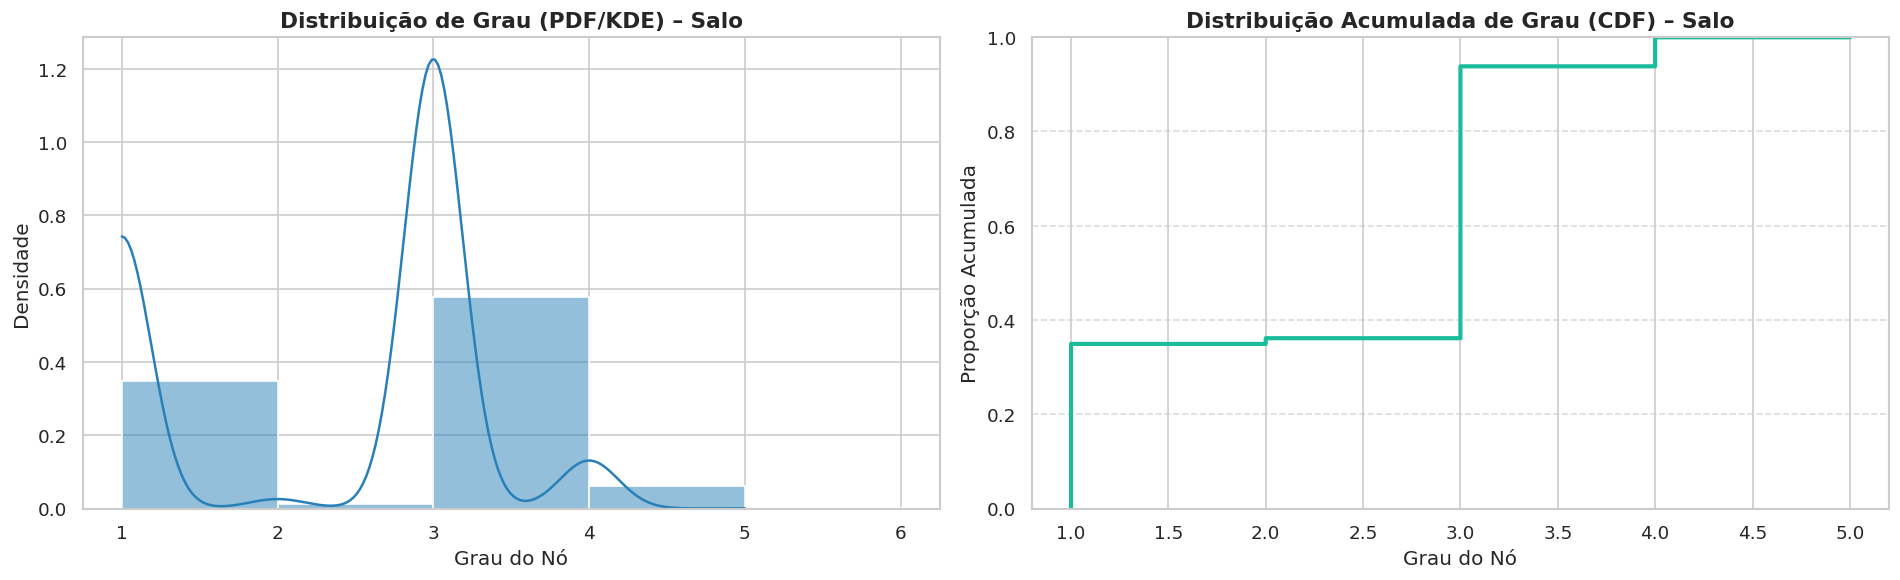

📸 Figura salva: fig02_distribuicao_grau.png


In [7]:
# --- Visualização: Distribuição de Grau ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# PDF / KDE
sns.histplot(degrees, bins=range(min(degrees), max(degrees) + 2),
             kde=True, color='#2980B9', stat="density", ax=axes[0])
axes[0].set_title('Distribuição de Grau (PDF/KDE) – Salo', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Grau do Nó')
axes[0].set_ylabel('Densidade')

# CDF
sns.ecdfplot(degrees, color='#1ABC9C', linewidth=2.5, ax=axes[1])
axes[1].set_title('Distribuição Acumulada de Grau (CDF) – Salo', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Grau do Nó')
axes[1].set_ylabel('Proporção Acumulada')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('fig02_distribuicao_grau.png', bbox_inches='tight', dpi=150)
plt.show()
print("📸 Figura salva: fig02_distribuicao_grau.png")

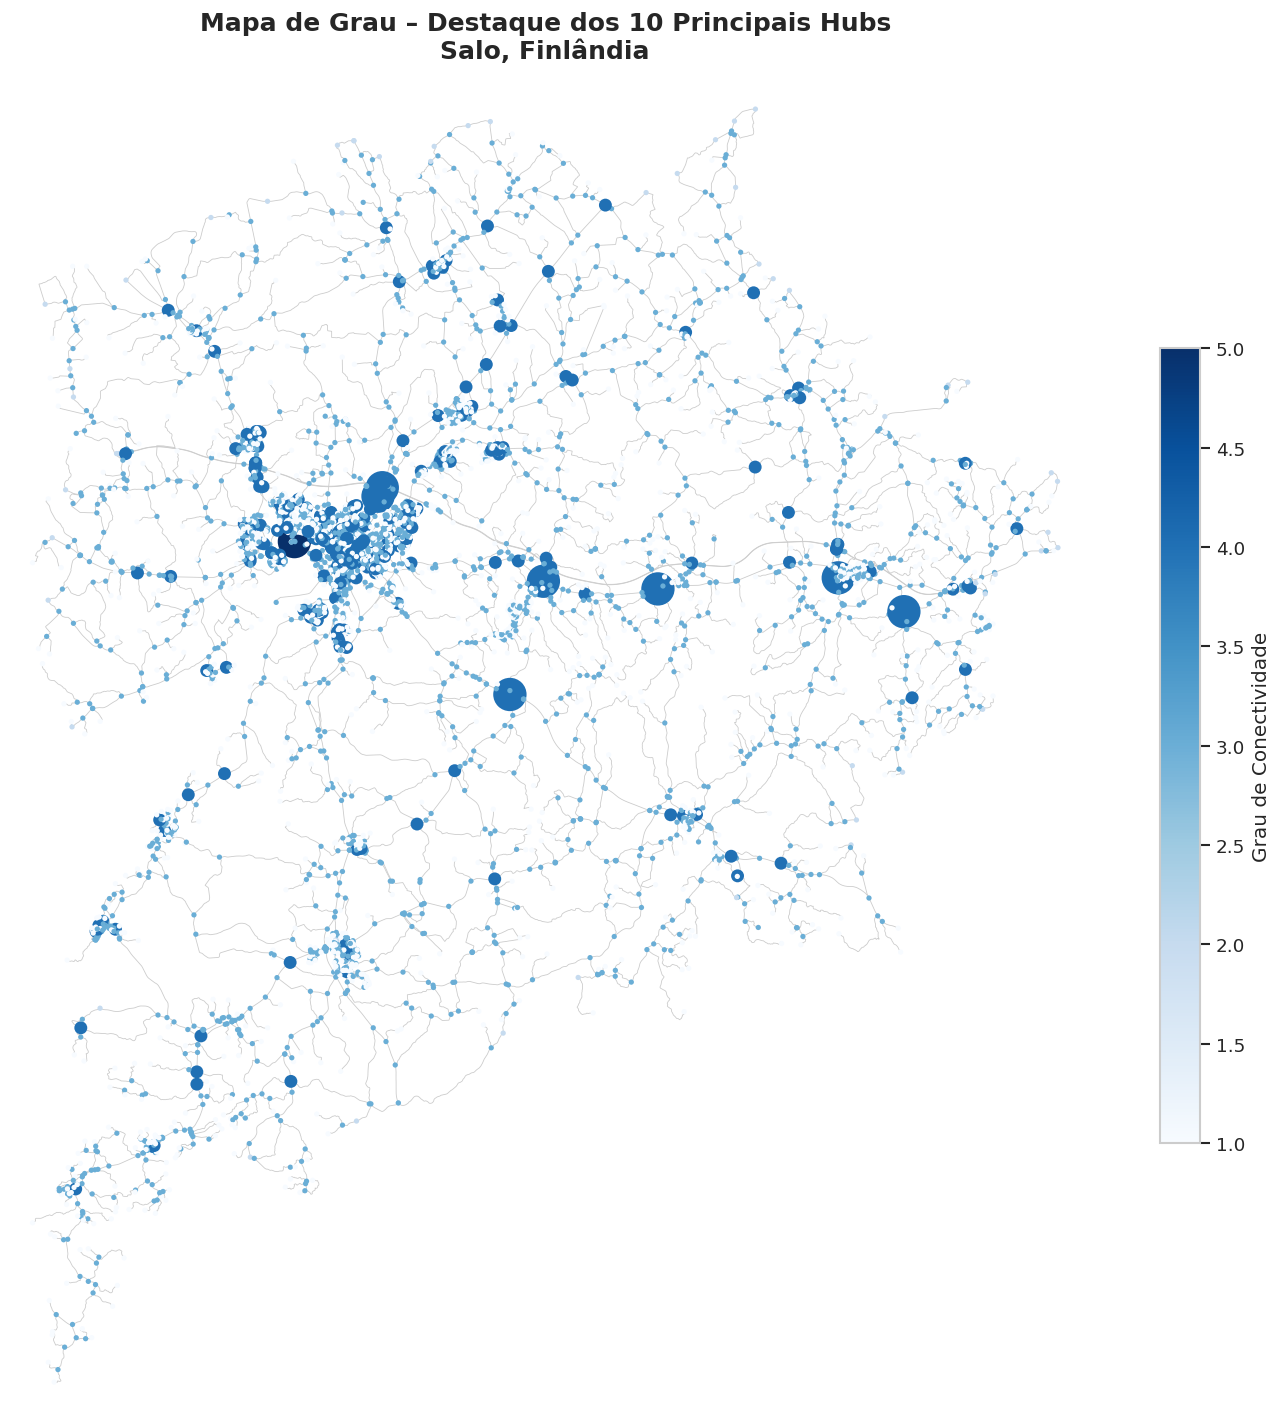

📸 Figura salva: fig03_hubs_map.png


In [8]:
# --- Mapa Geográfico: Top 10 Hubs ---
lista_id_hubs = [n[0] for n in top_degree]
graus_vals = np.array([degree_dict.get(n, 0) for n in G_undirected.nodes()])

node_sizes_map = []
for n in G_undirected.nodes():
    if n in lista_id_hubs:
        node_sizes_map.append(400)
    elif degree_dict.get(n, 0) >= 4:
        node_sizes_map.append(60)
    else:
        node_sizes_map.append(10)

norm_g = mcolors.Normalize(vmin=graus_vals.min(), vmax=graus_vals.max())
cmap_g = cm.Blues

fig, ax_map = plt.subplots(figsize=(14, 12))
ox.plot_graph(
    nx.MultiGraph(G_undirected),
    node_color=[cmap_g(norm_g(degree_dict.get(n, 0))) for n in G_undirected.nodes()],
    node_size=node_sizes_map,
    edge_color='#CCCCCC',
    edge_linewidth=0.5,
    bgcolor='white',
    ax=ax_map,
    show=False,
    close=False
)
ax_map.set_title("Mapa de Grau – Destaque dos 10 Principais Hubs\nSalo, Finlândia",
                 fontsize=15, fontweight='bold', pad=15)
sm = cm.ScalarMappable(norm=norm_g, cmap=cmap_g)
plt.colorbar(sm, ax=ax_map, label='Grau de Conectividade', shrink=0.6)
plt.tight_layout()
plt.savefig('fig03_hubs_map.png', bbox_inches='tight', dpi=150)
plt.show()
print("📸 Figura salva: fig03_hubs_map.png")

### 3.2 Betweenness Centrality (Eixos Críticos)

A **centralidade de intermediação** (*betweenness*) quantifica com que frequência um nó aparece no menor caminho entre todos os pares de nós da rede. Valores elevados indicam **pontos de gargalo**: remover ou sobrecarregar esses nós impacta desproporcionalmente a fluidez da rede.

Em Salo, os maiores valores de betweenness são esperados nas interseções que conectam o centro histórico às áreas periféricas e aos acessos à **Rodovia E18 (Turun moottoritie)**.

In [9]:
# Calculando Betweenness Centrality
print("⏳ Calculando Betweenness Centrality (k=500, pode levar alguns minutos)...")

if G_simple.number_of_nodes() > 10000:
    betweenness = nx.betweenness_centrality(G_simple, k=500, normalized=True, seed=42)
else:
    betweenness = nx.betweenness_centrality(G_simple, normalized=True)

nx.set_node_attributes(G_undirected, betweenness, 'betweenness')
print("✅ Betweenness centrality calculada!")

top_betweenness = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:10]
print("\n🎯 TOP 10 NÓS POR BETWEENNESS:")
print(f"  {'Rank':<5} {'Node ID':<15} {'Betweenness':<15}")
print(f"  {'-'*35}")
for i, (node, score) in enumerate(top_betweenness, 1):
    print(f"  {i:<5} {node:<15} {score:.6f}")

⏳ Calculando Betweenness Centrality (k=500, pode levar alguns minutos)...
✅ Betweenness centrality calculada!

🎯 TOP 10 NÓS POR BETWEENNESS:
  Rank  Node ID         Betweenness    
  -----------------------------------
  1     31196179        0.211959
  2     4343829980      0.192869
  3     3689437947      0.188240
  4     3689421658      0.183608
  5     1834994230      0.169457
  6     603159826       0.168463
  7     10012611        0.167422
  8     516702394       0.164995
  9     5517566328      0.164035
  10    5325353973      0.163994


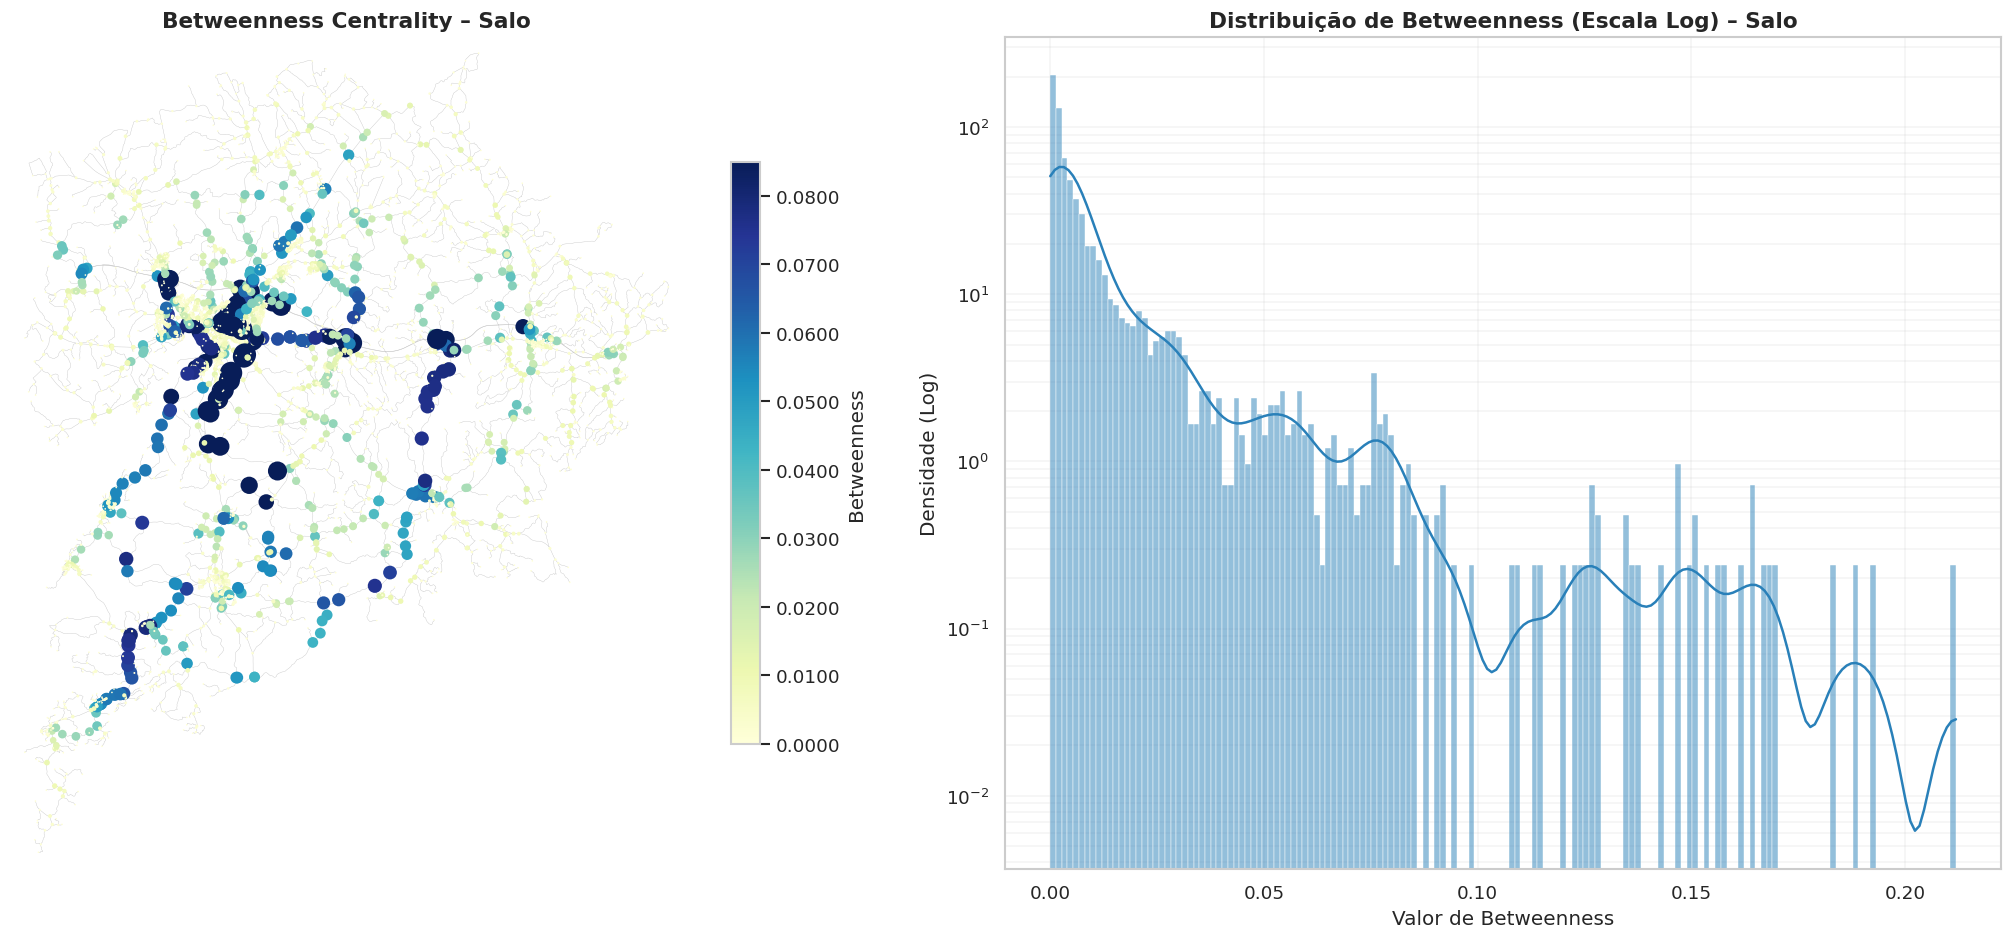

📸 Figura salva: fig04_betweenness.png


In [10]:
# --- Mapa Geográfico: Betweenness ---
betw_vals = np.array([betweenness.get(n, 0) for n in G_undirected.nodes()])
max_b_val = betw_vals.max()

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Mapa
norm_b = mcolors.Normalize(vmin=0, vmax=np.percentile(betw_vals, 99))
cmap_b = cm.YlGnBu
ox.plot_graph(
    G_undirected,
    node_color=[cmap_b(norm_b(v)) for v in betw_vals],
    node_size=[1 + 200 * v / (max_b_val + 1e-9) for v in betw_vals],
    edge_color='#BBBBBB',
    edge_linewidth=0.2,
    bgcolor='white',
    ax=axes[0],
    show=False,
    close=False
)
axes[0].set_title("Betweenness Centrality – Salo", fontsize=13, fontweight='bold')
sm = cm.ScalarMappable(norm=norm_b, cmap=cmap_b)
plt.colorbar(sm, ax=axes[0], label='Betweenness', format='%.4f', shrink=0.7)

# Distribuição (escala log)
vals_nonzero = betw_vals[betw_vals > 0]
sns.histplot(vals_nonzero, kde=True, color='#2980B9', stat="density", ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title("Distribuição de Betweenness (Escala Log) – Salo", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Valor de Betweenness")
axes[1].set_ylabel("Densidade (Log)")
axes[1].grid(True, which="both", ls="-", alpha=0.2)

plt.tight_layout()
plt.savefig('fig04_betweenness.png', bbox_inches='tight', dpi=150)
plt.show()
print("📸 Figura salva: fig04_betweenness.png")

### 3.3 Closeness Centrality (Acessibilidade Interna)

A **centralidade de proximidade** (*closeness*) mede o inverso da soma das distâncias topológicas de um nó a todos os outros. Nós com closeness alta conseguem alcançar qualquer outro ponto da rede em poucos saltos — em contexto urbano, isso reflete **acessibilidade potencial**.

> **Nota:** O closeness é calculado na Maior Componente Conectada (`G_connected`) para garantir que todos os nós se alcançam.

In [11]:
# Calculando Closeness Centrality
print("⏳ Calculando Closeness Centrality (pode demorar alguns minutos)...")
closeness = nx.closeness_centrality(G_connected)
nx.set_node_attributes(G_undirected, closeness, 'closeness')
print("✅ Closeness centrality calculada!")

top_closeness = sorted(closeness.items(), key=lambda x: x[1], reverse=True)[:10]
print("\n📍 TOP 10 NÓS POR CLOSENESS:")
print(f"  {'Rank':<5} {'Node ID':<15} {'Closeness':<15}")
print(f"  {'-'*35}")
for i, (node, score) in enumerate(top_closeness, 1):
    print(f"  {i:<5} {node:<15} {score:.6f}")

⏳ Calculando Closeness Centrality (pode demorar alguns minutos)...
✅ Closeness centrality calculada!

📍 TOP 10 NÓS POR CLOSENESS:
  Rank  Node ID         Closeness      
  -----------------------------------
  1     10012611        0.038458
  2     693343          0.038160
  3     742413463       0.038114
  4     315109354       0.038100
  5     693301          0.037907
  6     100155120       0.037879
  7     10012230        0.037876
  8     316315045       0.037860
  9     5517566328      0.037843
  10    693360          0.037796


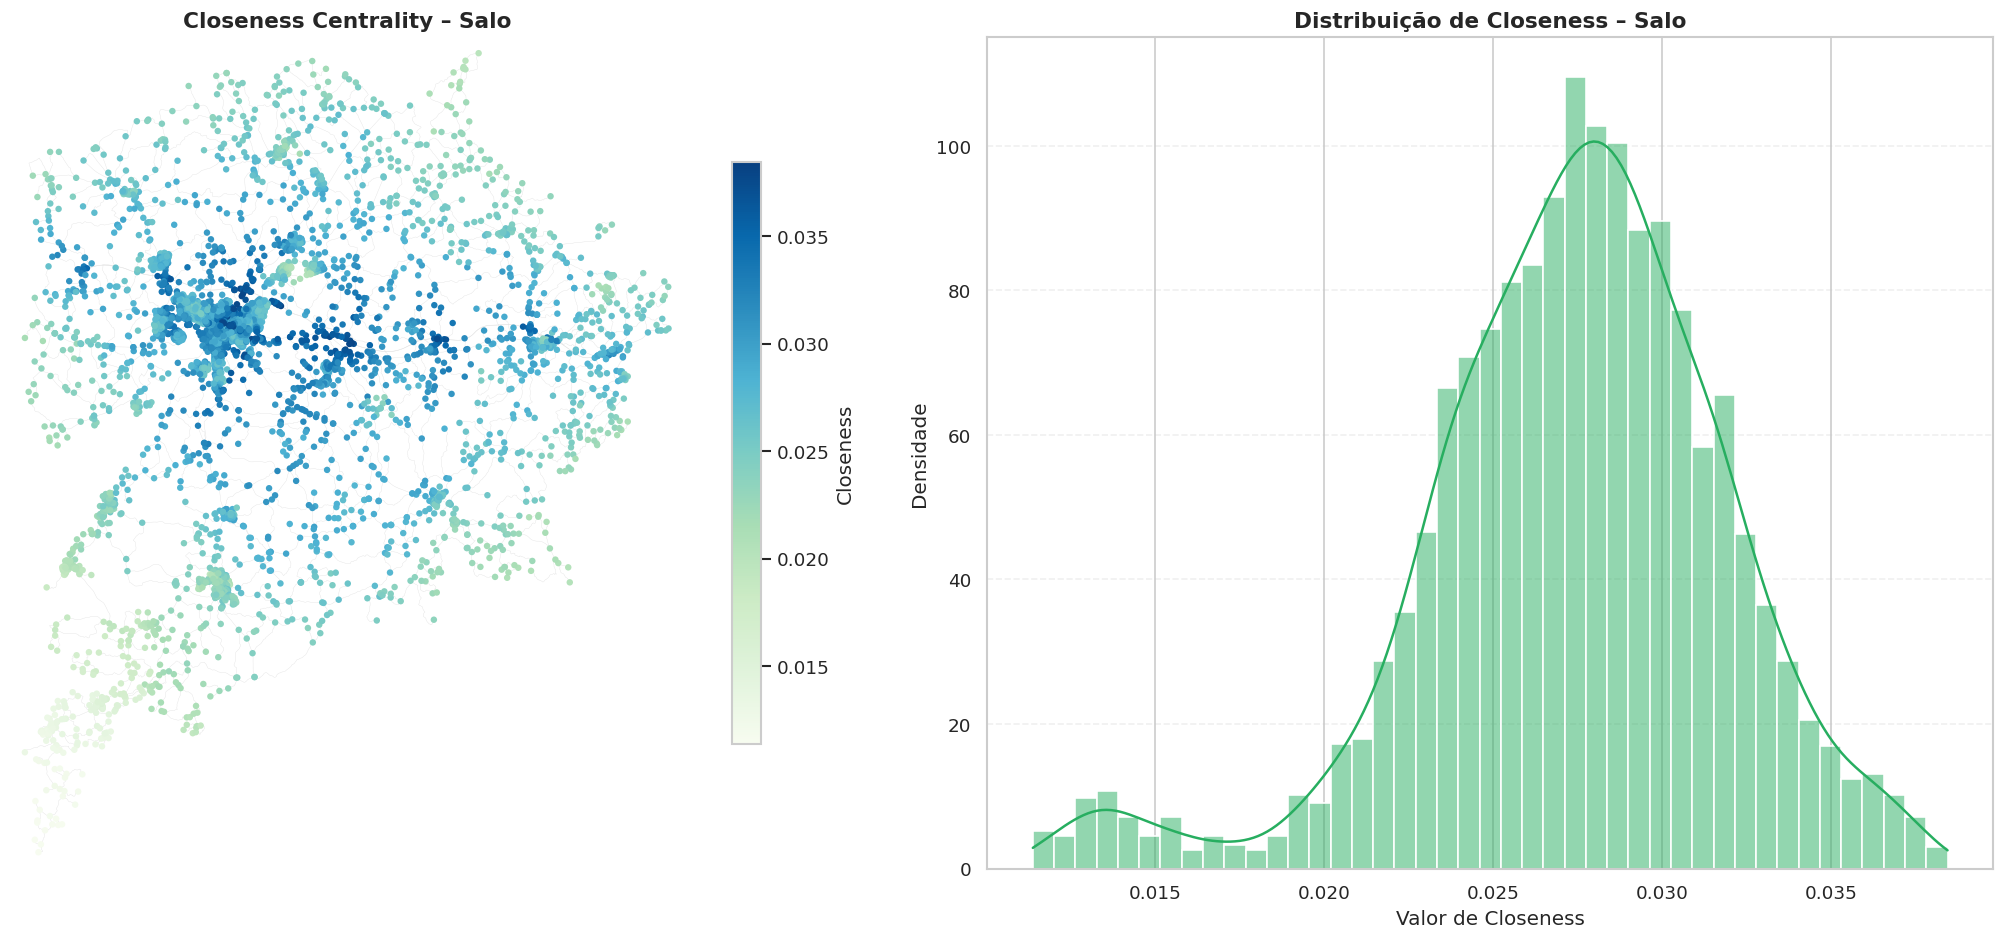

📸 Figura salva: fig05_closeness.png


In [12]:
# --- Mapa Geográfico: Closeness ---
close_vals = np.array([closeness.get(n, 0) for n in G_undirected.nodes()])

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

norm_c = mcolors.Normalize(vmin=close_vals.min(), vmax=close_vals.max())
cmap_c = cm.GnBu
ox.plot_graph(
    G_undirected,
    node_color=[cmap_c(norm_c(v)) for v in close_vals],
    node_size=15,
    edge_color='#DDDDDD',
    edge_linewidth=0.2,
    bgcolor='white',
    ax=axes[0],
    show=False,
    close=False
)
axes[0].set_title("Closeness Centrality – Salo", fontsize=13, fontweight='bold')
sm = cm.ScalarMappable(norm=norm_c, cmap=cmap_c)
plt.colorbar(sm, ax=axes[0], label='Closeness', format='%.3f', shrink=0.7)

# Distribuição
sns.histplot(close_vals[close_vals > 0], kde=True, color='#27AE60', stat="density", ax=axes[1])
axes[1].set_title("Distribuição de Closeness – Salo", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Valor de Closeness")
axes[1].set_ylabel("Densidade")
axes[1].grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('fig05_closeness.png', bbox_inches='tight', dpi=150)
plt.show()
print("📸 Figura salva: fig05_closeness.png")

### 3.4 K-Core e K-Shell Decomposition

A **decomposição k-core** descreve a estrutura hierárquica de coesão da rede. O *shell index* de um nó é o maior valor *k* para o qual ele pertence a um subgrafo onde todo nó tem grau ≥ k.

- **K-Shell:** revela as camadas concêntricas da rede, da periferia (k=1) ao núcleo mais denso.
- **Max K-Core:** o subgrafo mais coeso — em redes viárias, representa o "miolo" da malha onde a redundância de rotas é máxima.

Em Salo, o max k-core deve coincidir com o centro urbano densamente conectado, enquanto os shells externos correspondem às estradas rurais dos antigos municípios incorporados.

In [13]:
# Calculando K-Core
core_number = nx.core_number(G_simple)
max_k = max(core_number.values())
nx.set_node_attributes(G_undirected, core_number, 'shell_index')

cores = list(core_number.values())
core_counts = Counter(cores)
main_core_nodes = [node for node, core in core_number.items() if core == max_k]

print("="*50)
print("ANÁLISE DE K-CORE")
print("="*50)
print(f"  Maior core number (k-max): {max_k}")
print(f"\n  Distribuição dos Shells:")
for core_val in sorted(core_counts.keys()):
    pct = core_counts[core_val] / len(core_number) * 100
    print(f"    Shell {core_val}: {core_counts[core_val]:,} nós ({pct:.1f}%)")

print(f"\n🔷 NÚCLEO PRINCIPAL (k={max_k}):")
print(f"  Número de nós: {len(main_core_nodes):,}")
print(f"  Percentual da rede: {len(main_core_nodes)/len(G_undirected)*100:.2f}%")

ANÁLISE DE K-CORE
  Maior core number (k-max): 2

  Distribuição dos Shells:
    Shell 1: 2,280 nós (46.8%)
    Shell 2: 2,591 nós (53.2%)

🔷 NÚCLEO PRINCIPAL (k=2):
  Número de nós: 2,591
  Percentual da rede: 53.19%


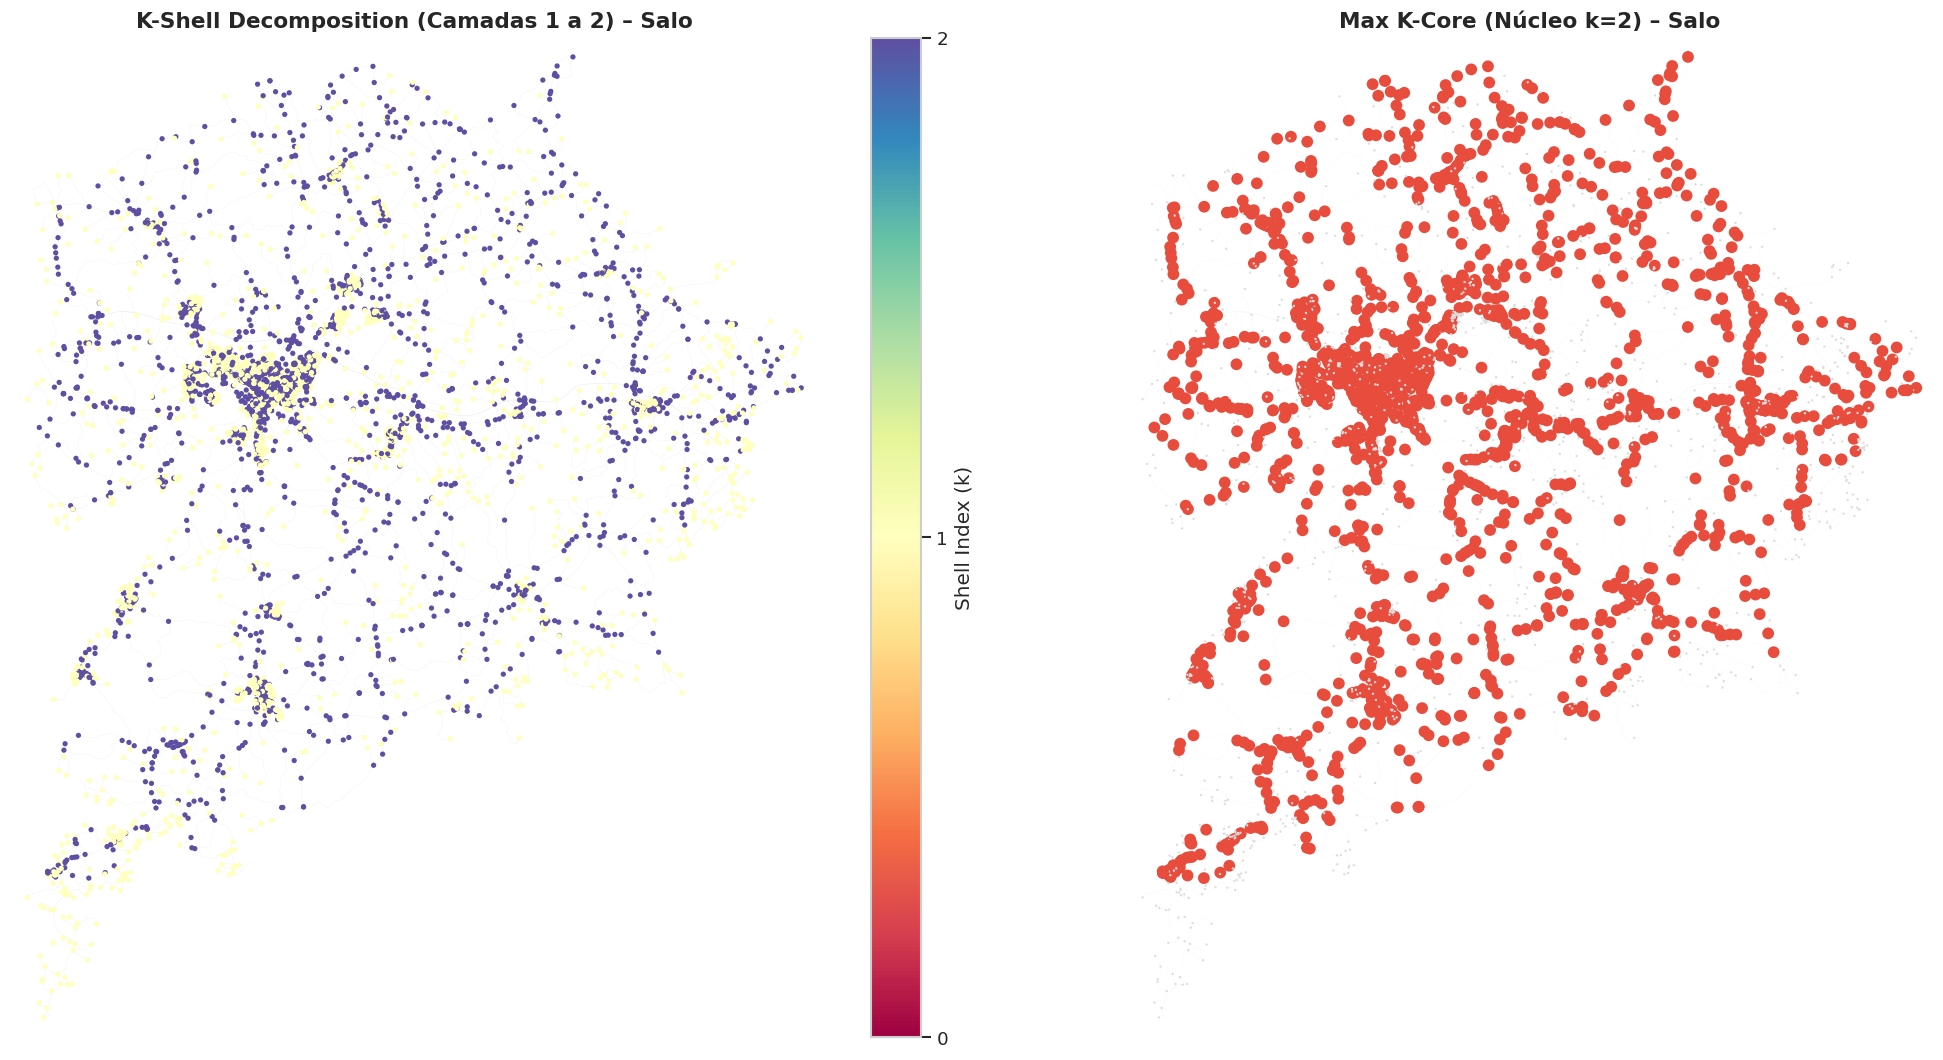

📸 Figura salva: fig06_kcore_kshell.png


In [14]:
# --- Visualização: K-Shell e K-Core ---
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# K-Shell (todas as camadas)
norm_shell = mcolors.Normalize(vmin=0, vmax=max_k)
cmap_shell = cm.Spectral
ox.plot_graph(
    G_undirected,
    node_color=[cmap_shell(norm_shell(core_number.get(n, 0))) for n in G_undirected.nodes()],
    node_size=10,
    edge_color='#DDDDDD',
    edge_linewidth=0.1,
    bgcolor='white',
    ax=axes[0],
    show=False,
    close=False
)
axes[0].set_title(f"K-Shell Decomposition (Camadas 1 a {max_k}) – Salo", fontsize=13, fontweight='bold')
sm1 = cm.ScalarMappable(norm=norm_shell, cmap=cmap_shell)
plt.colorbar(sm1, ax=axes[0], label='Shell Index (k)', ticks=range(max_k + 1))

# Max K-Core (destaque do núcleo)
max_core_nodes_set = set(n for n, k in core_number.items() if k == max_k)
node_colors_core = ['#E74C3C' if n in max_core_nodes_set else '#DDDDDD' for n in G_undirected.nodes()]
node_sizes_core = [50 if n in max_core_nodes_set else 2 for n in G_undirected.nodes()]
ox.plot_graph(
    G_undirected,
    node_color=node_colors_core,
    node_size=node_sizes_core,
    edge_color='#EEEEEE',
    edge_linewidth=0.1,
    bgcolor='white',
    ax=axes[1],
    show=False,
    close=False
)
axes[1].set_title(f"Max K-Core (Núcleo k={max_k}) – Salo", fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('fig06_kcore_kshell.png', bbox_inches='tight', dpi=150)
plt.show()
print("📸 Figura salva: fig06_kcore_kshell.png")

### 3.5 Eigenvector Centrality (Influência por Vizinhança)

A **centralidade de autovetor** (*eigenvector*) mede a influência de um nó levando em conta não apenas quantas conexões ele possui, mas **a importância dos seus vizinhos**. Um nó com poucos vizinhos, mas altamente conectados, pode ter eigenvector alto — ao contrário do grau, que trata todas as conexões como iguais.

In [15]:
# Calculando Eigenvector Centrality
print("⏳ Calculando Eigenvector Centrality...")
G_calc = nx.Graph(G_undirected)

try:
    eigenvector = nx.eigenvector_centrality(G_calc, max_iter=2000, tol=1e-06)
    print("✅ Eigenvector calculado pelo método iterativo.")
except (nx.PowerIterationFailedConvergence, nx.NetworkXError):
    print("⚠️  Método iterativo não convergiu. Usando método NumPy...")
    eigenvector = nx.eigenvector_centrality_numpy(G_calc)
    print("✅ Eigenvector calculado pelo método NumPy.")

nx.set_node_attributes(G_undirected, eigenvector, 'eigenvector')
eig_vals = np.array([eigenvector.get(n, 0) for n in G_undirected.nodes()])

top_eigenvector = sorted(eigenvector.items(), key=lambda x: x[1], reverse=True)[:10]
print(f"\n   Valor máximo de eigenvector: {eig_vals.max():.6f}")
print("\n⭐ TOP 10 NÓS POR EIGENVECTOR:")
print(f"  {'Rank':<5} {'Node ID':<15} {'Eigenvector':<15}")
print(f"  {'-'*35}")
for i, (node, score) in enumerate(top_eigenvector, 1):
    print(f"  {i:<5} {node:<15} {score:.6f}")

⏳ Calculando Eigenvector Centrality...
✅ Eigenvector calculado pelo método iterativo.

   Valor máximo de eigenvector: 0.261611

⭐ TOP 10 NÓS POR EIGENVECTOR:
  Rank  Node ID         Eigenvector    
  -----------------------------------
  1     114127052       0.261611
  2     112044633       0.257527
  3     112044831       0.239608
  4     112044763       0.222275
  5     112044783       0.214989
  6     114127081       0.213010
  7     2840801178      0.197722
  8     100155196       0.196325
  9     110268010       0.191787
  10    2840801175      0.188989


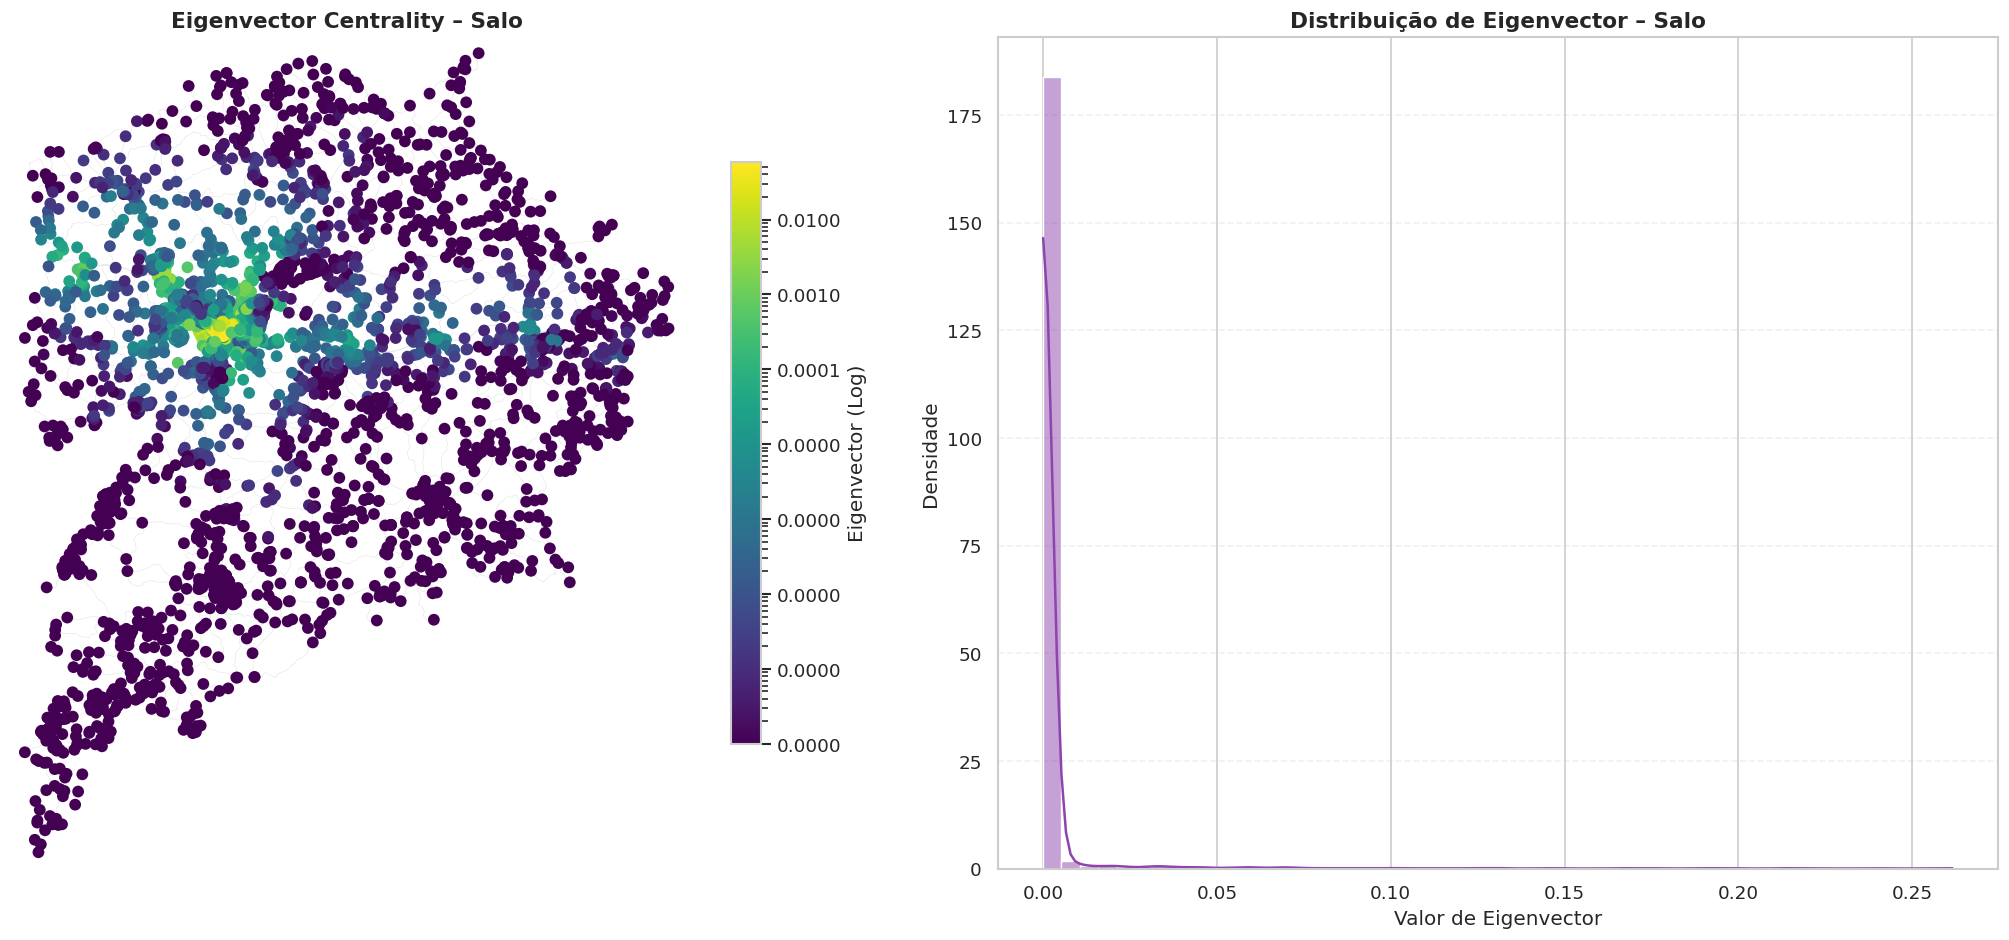

📸 Figura salva: fig07_eigenvector.png


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns
import osmnx as ox

# --- Mapa Geográfico: Eigenvector ---
eig_vals_clipped = np.clip(eig_vals, 1e-9, None)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

norm_e = mcolors.LogNorm(vmin=eig_vals_clipped.min(), vmax=np.percentile(eig_vals_clipped, 99))
cmap_e = cm.viridis
ox.plot_graph(
    nx.MultiGraph(G_undirected),
    node_color=[cmap_e(norm_e(v)) for v in eig_vals_clipped],
    node_size=50,
    edge_color='#E0E0E0',
    edge_linewidth=0.3,
    bgcolor='white',
    ax=axes[0],
    show=False,
    close=False
)
axes[0].set_title("Eigenvector Centrality – Salo", fontsize=13, fontweight='bold')
sm = cm.ScalarMappable(norm=norm_e, cmap=cmap_e)
plt.colorbar(sm, ax=axes[0], label='Eigenvector (Log)', format='%.4f', shrink=0.7)

# Distribuição
sns.histplot(eig_vals[eig_vals > 0], kde=True, color='#8E44AD', stat="density", ax=axes[1], bins=50)
axes[1].set_title("Distribuição de Eigenvector – Salo", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Valor de Eigenvector")
axes[1].set_ylabel("Densidade")
axes[1].grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('fig07_eigenvector.png', bbox_inches='tight', dpi=150)
plt.show()
print("📸 Figura salva: fig07_eigenvector.png")

---
## Etapa 4 – Análise Comparativa das Métricas

O **PairGrid** a seguir cruza as cinco métricas calculadas para identificar correlações e dissociações que revelem a estrutura funcional da cidade de Salo.

In [18]:
# Tabela comparativa dos principais nós
all_top_nodes = set(
    [n for n, _ in top_degree[:20]] +
    [n for n, _ in top_betweenness[:20]] +
    [n for n, _ in top_closeness[:20]] +
    [n for n, _ in top_eigenvector[:20]] +
    main_core_nodes[:20]
)

analysis_data = []
for node in all_top_nodes:
    analysis_data.append({
        'Node': node,
        'Grau': degree_dict.get(node, 0),
        'Betweenness': round(betweenness.get(node, 0), 6),
        'Closeness': round(closeness.get(node, 0), 6),
        'Eigenvector': round(eigenvector.get(node, 0), 6),
        'Shell_Index': core_number.get(node, 0)
    })

df_analysis = pd.DataFrame(analysis_data).sort_values('Betweenness', ascending=False)
print("📊 TABELA COMPARATIVA DOS PRINCIPAIS NÓS (ordenado por Betweenness):")
print(df_analysis.to_string(index=False))

📊 TABELA COMPARATIVA DOS PRINCIPAIS NÓS (ordenado por Betweenness):
      Node  Grau  Betweenness  Closeness  Eigenvector  Shell_Index
  31196179     3     0.211959   0.037607     0.003074            2
4343829980     3     0.192869   0.037147     0.001156            2
3689437947     3     0.188240   0.036303     0.000173            2
3689421658     3     0.183608   0.036725     0.000432            2
1834994230     3     0.169457   0.037475     0.008314            2
 603159826     3     0.168463   0.035772     0.000064            2
  10012611     3     0.167422   0.038458     0.000060            2
 516702394     4     0.164995   0.034737     0.000010            2
5517566328     4     0.164035   0.037843     0.018407            2
5325353973     3     0.163994   0.035230     0.000024            2
 315109354     3     0.161166   0.038100     0.000030            2
 742413463     3     0.147384   0.038114     0.000145            2
  10012230     3     0.147248   0.037876     0.000387        

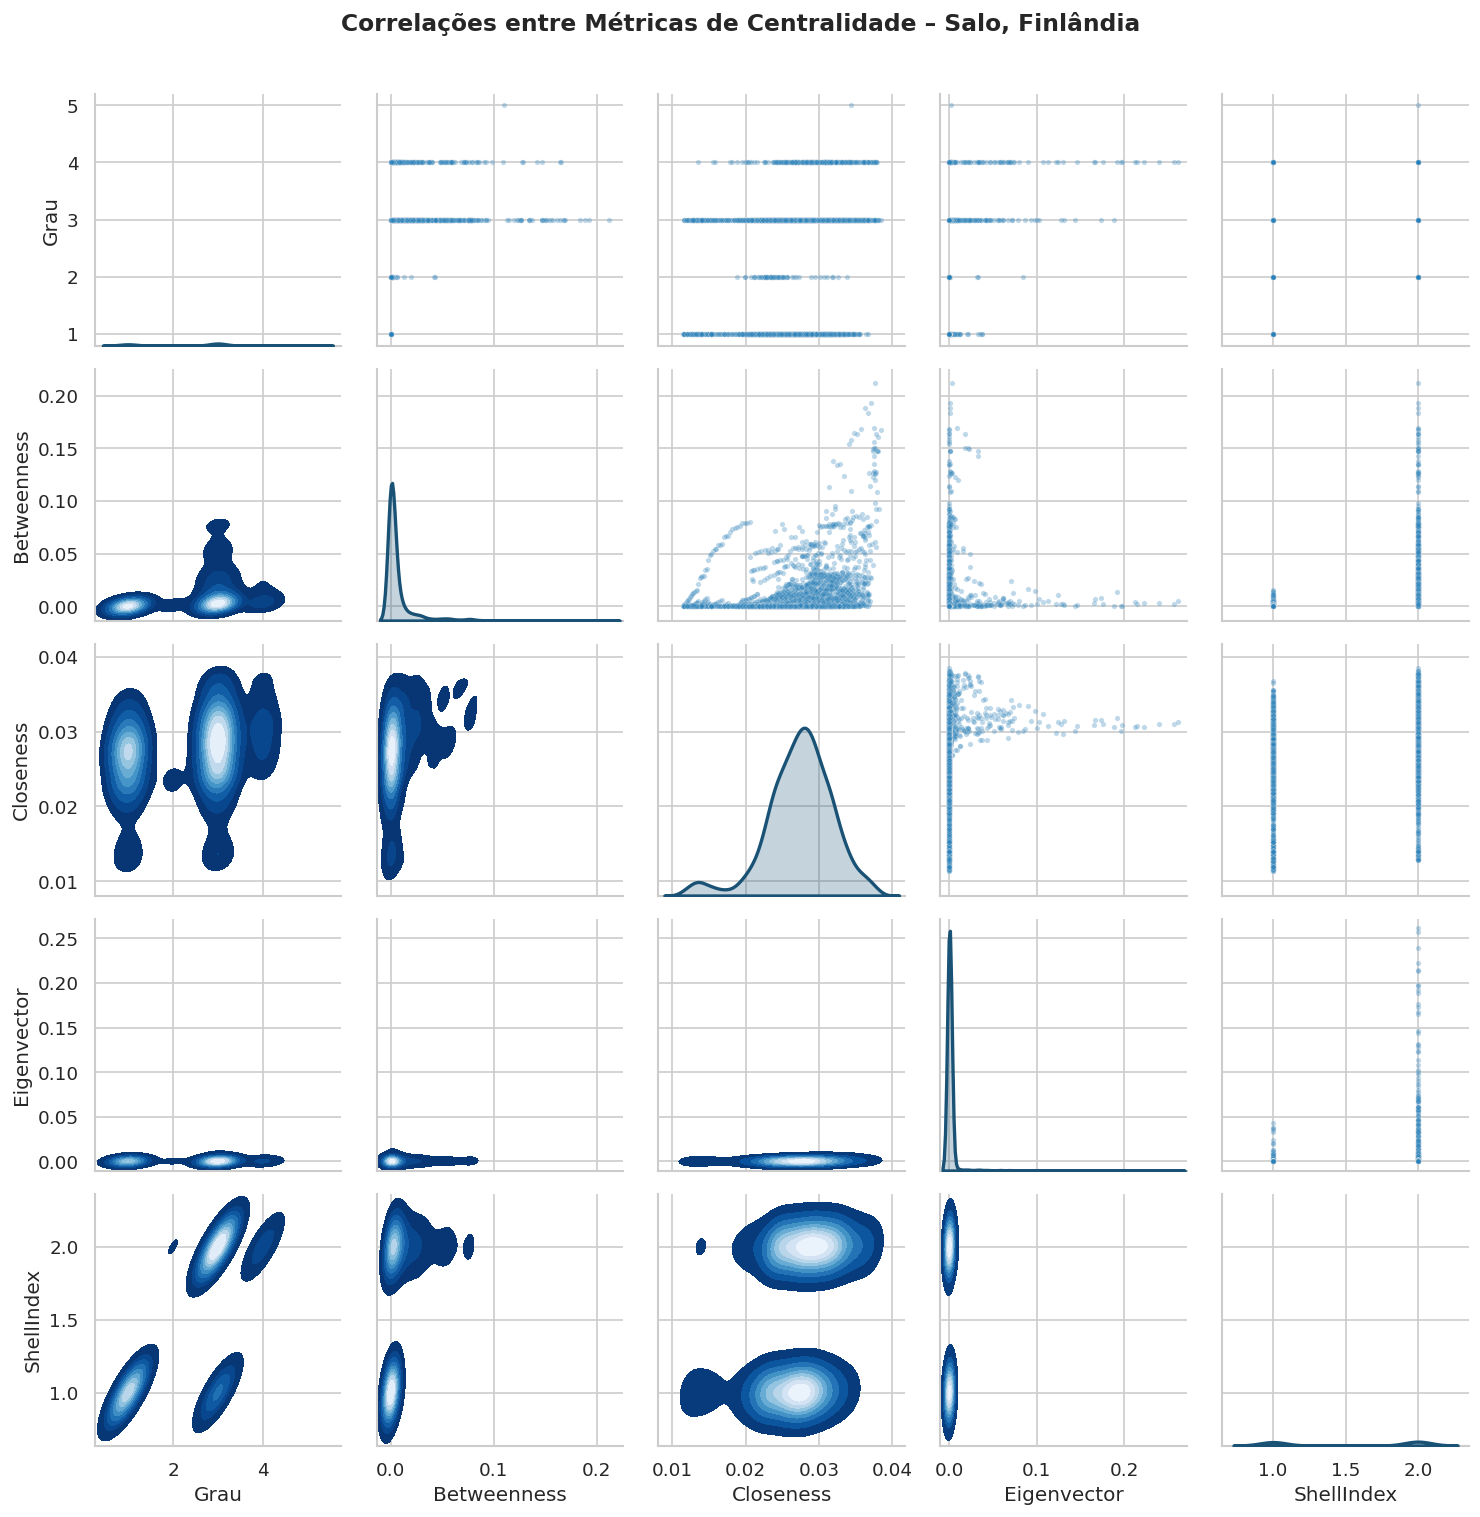

📸 Figura salva: fig08_pairgrid_metricas.png


In [19]:
# PairGrid: Correlações entre todas as métricas
nodes_data = []
for node in G_simple.nodes():
    nodes_data.append({
        'Grau': degree_dict.get(node, 0),
        'Betweenness': betweenness.get(node, 0),
        'Closeness': closeness.get(node, 0),
        'Eigenvector': eigenvector.get(node, 0),
        'ShellIndex': core_number.get(node, 0)
    })

df_all = pd.DataFrame(nodes_data)

g = sns.PairGrid(df_all)
g.map_upper(sns.scatterplot, s=10, alpha=0.3, color='#2980B9')
g.map_lower(sns.kdeplot, cmap="Blues_r", fill=True)
g.map_diag(sns.kdeplot, lw=2, color='#1A5276', fill=True)
plt.suptitle('Correlações entre Métricas de Centralidade – Salo, Finlândia',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig08_pairgrid_metricas.png', bbox_inches='tight', dpi=120)
plt.show()
print("📸 Figura salva: fig08_pairgrid_metricas.png")

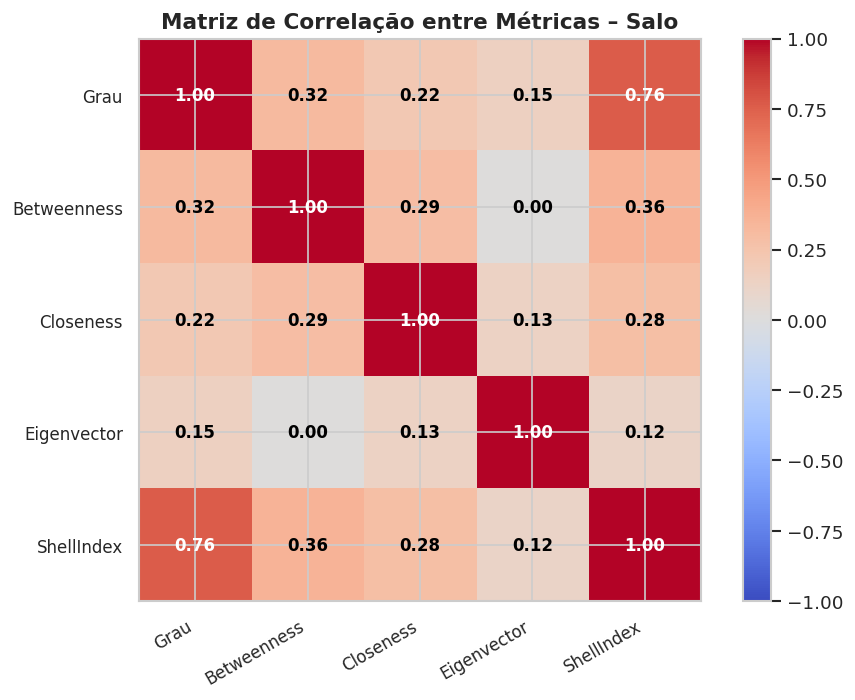

📸 Figura salva: fig09_matriz_correlacao.png


In [20]:
# Matriz de Correlação
corr = df_all.corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
labels = ['Grau', 'Betweenness', 'Closeness', 'Eigenvector', 'ShellIndex']
ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(labels, fontsize=10, rotation=30, ha='right')
ax.set_yticklabels(labels, fontsize=10)
for i in range(5):
    for j in range(5):
        color = "white" if abs(corr.values[i, j]) > 0.5 else "black"
        ax.text(j, i, f'{corr.values[i, j]:.2f}', ha="center", va="center",
                color=color, fontsize=10, fontweight='bold')
ax.set_title('Matriz de Correlação entre Métricas – Salo', fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('fig09_matriz_correlacao.png', bbox_inches='tight', dpi=150)
plt.show()
print("📸 Figura salva: fig09_matriz_correlacao.png")

---
## Etapa 5 – Exportação para Gephi 0.11.2

### Por que o mapa aparece como mancha preta no Gephi?

O problema ocorre por **três razões combinadas**:

| Causa | O que acontece |
|---|---|
| **Coordenadas em graus decimais brutos** | Longitude ~23° e Latitude ~60° → o Gephi interpreta como pixels, sobrepondo todos os nós num ponto minúsculo |
| **Nós com tamanho padrão grande** | Sem `node_size` definido, o Gephi usa tamanho padrão que cobre tudo |
| **Cor preta padrão** | Sem atributo de cor, todos os nós ficam pretos e se fundem |

### Solução adotada: pré-posicionamento das coordenadas

Em vez de depender do **Geo Layout** do Gephi, a exportação já insere as coordenadas `viz_x` e `viz_y` **normalizadas e escaladas** diretamente no arquivo GEXF, usando o elemento `<viz:position>` nativo do formato. Isso faz o mapa aparecer **corretamente posicionado ao abrir o arquivo**, sem nenhum passo adicional.

O arquivo gerado também inclui `viz:size` e `viz:color` pré-configurados baseados nas métricas calculadas.

In [21]:
import math
import xml.etree.ElementTree as ET

def export_for_gephi_0_11_2(G_input, city_name="salo_finland"):
    """
    Exporta grafo para GEXF com posições geográficas pré-calculadas.

    Solução para a mancha preta no Gephi 0.11.2:
    - Normaliza lon/lat para coordenadas de tela (viz:position)
    - Define viz:size proporcional ao grau
    - Define viz:color por shell_index
    - Gera grafo simples sem MultiEdges e sem atributos incompatíveis
    """

    CANVAS = 10000.0  # tamanho do canvas virtual do Gephi

    def safe_float(v):
        try:
            f = float(v)
            return 0.0 if (math.isnan(f) or math.isinf(f)) else f
        except:
            return 0.0

    def safe_str(v):
        if v is None: return ""
        if isinstance(v, list): return "|".join(str(i) for i in v)
        return str(v)

    # ── 1. Coletar coordenadas geográficas reais dos nós ─────────────────────
    lons, lats = [], []
    for node, data in G_input.nodes(data=True):
        lons.append(safe_float(data.get('x', 0)))
        lats.append(safe_float(data.get('y', 0)))

    lon_min, lon_max = min(lons), max(lons)
    lat_min, lat_max = min(lats), max(lats)
    lon_range = lon_max - lon_min or 1
    lat_range = lat_max - lat_min or 1

    # ── 2. Coletar métricas para normalizar tamanho e cor ────────────────────
    graus      = {n: safe_float(d.get('grau', 1))        for n, d in G_input.nodes(data=True)}
    shells     = {n: safe_float(d.get('shell_index', 0)) for n, d in G_input.nodes(data=True)}
    betw_vals2 = {n: safe_float(d.get('betweenness', 0)) for n, d in G_input.nodes(data=True)}

    max_grau   = max(graus.values()) or 1
    max_shell  = max(shells.values()) or 1
    max_betw   = max(betw_vals2.values()) or 1

    # Paleta de cor por shell_index: azul(k=1) → amarelo → vermelho(k=max)
    # Usando colormap viridis discreto
    import matplotlib.cm as _cm
    import matplotlib.colors as _mc
    _cmap = _cm.get_cmap('plasma')
    def shell_to_rgb(shell_val):
        r, g, b, _ = _cmap(shell_val / max_shell)
        return int(r*255), int(g*255), int(b*255)

    # ── 3. Construir grafo simples limpo ─────────────────────────────────────
    G_export = nx.Graph()
    NUMERIC = {'grau','betweenness','closeness','eigenvector','shell_index','x','y'}
    STRING  = {'osmid','name','highway','ref'}

    for node, data in G_input.nodes(data=True):
        clean = {}
        for k, v in data.items():
            if k == 'geometry' or isinstance(v, (dict, list)): continue
            if k in NUMERIC:  clean[k] = safe_float(v)
            elif k in STRING: clean[k] = safe_str(v)
        G_export.add_node(node, **clean)

    seen = set()
    for u, v, data in G_input.edges(data=True):
        key = (min(u,v), max(u,v))
        if key in seen: continue
        seen.add(key)
        clean_e = {}
        if 'length' in data: clean_e['length'] = safe_float(data['length'])
        if 'highway' in data: clean_e['highway'] = safe_str(data['highway'])
        G_export.add_edge(u, v, **clean_e)

    # ── 4. Escrever GEXF manualmente com viz:position, viz:size, viz:color ──
    gexf_path = f"{city_name}_gephi.gexf"

    lines = [
        '<?xml version="1.0" encoding="UTF-8"?>',
        '<gexf xmlns="http://gexf.net/1.2"',
        '      xmlns:viz="http://gexf.net/1.2/viz"',
        '      xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance"',
        '      xsi:schemaLocation="http://gexf.net/1.2 http://gexf.net/1.2/gexf.xsd"',
        '      version="1.2">',
        '  <meta lastmodifieddate="2024-01-01">',
        '    <creator>OSMnx + NetworkX</creator>',
        f'   <description>Rede viária de {city_name}</description>',
        '  </meta>',
        '  <graph defaultedgetype="undirected">',
        '    <attributes class="node">',
        '      <attribute id="0" title="grau"        type="double"/>',
        '      <attribute id="1" title="betweenness"  type="double"/>',
        '      <attribute id="2" title="closeness"    type="double"/>',
        '      <attribute id="3" title="eigenvector"  type="double"/>',
        '      <attribute id="4" title="shell_index"  type="integer"/>',
        '      <attribute id="5" title="longitude"    type="double"/>',
        '      <attribute id="6" title="latitude"     type="double"/>',
        '    </attributes>',
        '    <attributes class="edge">',
        '      <attribute id="10" title="length" type="double"/>',
        '    </attributes>',
        '    <nodes>',
    ]

    for node, data in G_export.nodes(data=True):
        lon = safe_float(data.get('x', 0))
        lat = safe_float(data.get('y', 0))

        # Normalizar coordenadas para o canvas do Gephi
        # Latitude precisa ser invertida (Y cresce para baixo no Gephi)
        vx = ((lon - lon_min) / lon_range) * CANVAS
        vy = ((lat - lat_min) / lat_range) * CANVAS  # NÃO inverte: Gephi usa Y para cima

        # Tamanho: 2 a 20, proporcional ao grau
        grau_n = graus.get(node, 1)
        viz_size = 2.0 + 18.0 * (grau_n / max_grau)

        # Cor por shell_index
        shell_n = shells.get(node, 0)
        r, g, b = shell_to_rgb(shell_n)

        node_id = str(node).replace('&','').replace('<','').replace('>','')

        lines.append(f'      <node id="{node_id}" label="{node_id}">')
        lines.append(f'        <attvalues>')
        lines.append(f'          <attvalue for="0" value="{data.get("grau", 0)}"/>')
        lines.append(f'          <attvalue for="1" value="{data.get("betweenness", 0)}"/>')
        lines.append(f'          <attvalue for="2" value="{data.get("closeness", 0)}"/>')
        lines.append(f'          <attvalue for="3" value="{data.get("eigenvector", 0)}"/>')
        lines.append(f'          <attvalue for="4" value="{int(shell_n)}"/>')
        lines.append(f'          <attvalue for="5" value="{lon}"/>')
        lines.append(f'          <attvalue for="6" value="{lat}"/>')
        lines.append(f'        </attvalues>')
        lines.append(f'        <viz:position x="{vx:.4f}" y="{vy:.4f}" z="0.0"/>')
        lines.append(f'        <viz:size value="{viz_size:.2f}"/>')
        lines.append(f'        <viz:color r="{r}" g="{g}" b="{b}"/>')
        lines.append( '      </node>')

    lines.append('    </nodes>')
    lines.append('    <edges>')

    for eid, (u, v, data) in enumerate(G_export.edges(data=True)):
        uid = str(u).replace('&','').replace('<','').replace('>','')
        vid = str(v).replace('&','').replace('<','').replace('>','')
        length_val = data.get('length', 0.0)
        lines.append(f'      <edge id="{eid}" source="{uid}" target="{vid}">')
        lines.append(f'        <attvalues><attvalue for="10" value="{length_val}"/></attvalues>')
        lines.append( '      </edge>')

    lines += ['    </edges>', '  </graph>', '</gexf>']

    with open(gexf_path, 'w', encoding='utf-8') as f:
        f.write('\n'.join(lines))

    # Também salva GraphML simples como backup
    graphml_path = f"{city_name}_gephi.graphml"
    nx.write_graphml(G_export, graphml_path)

    print(f"  Nós exportados:     {G_export.number_of_nodes():,}")
    print(f"  Arestas exportadas: {G_export.number_of_edges():,}")
    print(f"  Canvas normalizado: lon [{lon_min:.4f} → {lon_max:.4f}] → [0 → {CANVAS:.0f}]")
    print(f"                      lat [{lat_min:.4f} → {lat_max:.4f}] → [0 → {CANVAS:.0f}]")
    print(f"\n  ✅ GEXF (com posições)  salvo: {gexf_path}")
    print(f"  ✅ GraphML (backup)     salvo: {graphml_path}")
    return G_export, graphml_path, gexf_path


print("="*60)
print("EXPORTANDO PARA GEPHI 0.11.2 (com posições pré-calculadas)")
print("="*60)
G_export, graphml_path, gexf_path = export_for_gephi_0_11_2(G_undirected, "salo_finland")


EXPORTANDO PARA GEPHI 0.11.2 (com posições pré-calculadas)
  Nós exportados:     4,871
  Arestas exportadas: 5,680
  Canvas normalizado: lon [22.8406 → 23.7898] → [0 → 10000]
                      lat [60.0065 → 60.5904] → [0 → 10000]

  ✅ GEXF (com posições)  salvo: salo_finland_gephi.gexf
  ✅ GraphML (backup)     salvo: salo_finland_gephi.graphml


In [22]:
# ── Verificação de integridade do arquivo exportado ─────────────────────────
print("🔍 VERIFICAÇÃO DE INTEGRIDADE DOS ARQUIVOS EXPORTADOS")
print("="*55)

# Teste: recarregar o GraphML
try:
    G_test_graphml = nx.read_graphml(graphml_path)
    print(f"  GraphML: ✅ OK — {G_test_graphml.number_of_nodes():,} nós, "
          f"{G_test_graphml.number_of_edges():,} arestas")
    sample_attrs = list(list(G_test_graphml.nodes(data=True))[0][1].keys())
    print(f"           Atributos: {sample_attrs}")
except Exception as e:
    print(f"  GraphML: ❌ ERRO — {e}")

# Teste: recarregar o GEXF
try:
    G_test_gexf = nx.read_gexf(gexf_path)
    print(f"\n  GEXF   : ✅ OK — {G_test_gexf.number_of_nodes():,} nós, "
          f"{G_test_gexf.number_of_edges():,} arestas")
    sample_attrs_g = list(list(G_test_gexf.nodes(data=True))[0][1].keys())
    print(f"           Atributos: {sample_attrs_g}")
except Exception as e:
    print(f"\n  GEXF   : ❌ ERRO — {e}")

# Tamanho dos arquivos
import os
for path in [graphml_path, gexf_path]:
    size_mb = os.path.getsize(path) / (1024 * 1024)
    print(f"\n  📁 {path}: {size_mb:.2f} MB")

🔍 VERIFICAÇÃO DE INTEGRIDADE DOS ARQUIVOS EXPORTADOS
  GraphML: ✅ OK — 4,871 nós, 5,680 arestas
           Atributos: ['y', 'x', 'highway', 'ref', 'grau', 'betweenness', 'closeness', 'shell_index', 'eigenvector']

  GEXF   : ❌ ERRO — No <graph> element in GEXF file.

  📁 salo_finland_gephi.graphml: 2.06 MB

  📁 salo_finland_gephi.gexf: 3.58 MB


---
## Etapa 6 – Instruções de Importação no Gephi 0.11.2

```
╔══════════════════════════════════════════════════════════════╗
║       INSTRUÇÕES PARA O GEPHI 0.11.2 (arquivo com posições) ║
╚══════════════════════════════════════════════════════════════╝

ARQUIVO:  salo_finland_gephi.gexf
          (já contém posições geográficas pré-calculadas)

━━━ IMPORTAÇÃO ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. File → Open → selecione salo_finland_gephi.gexf
2. No diálogo: Graph Type = Undirected → OK
3. O mapa de Salo aparecerá IMEDIATAMENTE posicionado.
   ► NÃO é necessário rodar nenhum Layout adicional.

━━━ SE QUISER AJUSTAR A APARÊNCIA ━━━━━━━━━━━━━━━━━━━━━━━━━━━
Tamanho (Appearance → Nodes → Size → Ranking):
  - Atributo: grau  |  Min: 2  |  Max: 20  → Apply

Cor (Appearance → Nodes → Color → Ranking):
  - Atributo: shell_index → paleta Plasma → Apply
  - Ou:       betweenness → paleta YlOrRd → Apply

━━━ VISUALIZAÇÃO ESTRUTURAL (ForceAtlas 2) ━━━━━━━━━━━━━━━━━━
Layout → ForceAtlas 2
  - Scaling: 5.0  |  Gravity: 1.0  |  Run ~1 min → Stop

━━━ FILTROS RECOMENDADOS ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Filters → Topology → Degree Range → mínimo 2 (remove becos)
Filters → Attributes → Range → shell_index ≥ 2

━━━ DATA LABORATORY ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Confirme que as colunas existem na aba Nodes:
  grau | betweenness | closeness | eigenvector | shell_index
  longitude | latitude

━━━ EXPORTAÇÃO DE IMAGEM ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
File → Export → SVG/PDF/PNG
Resolução: 3000 × 3000 px, DPI: 300
```


---
## Etapa 7 – Relatório Final e Insights

In [23]:
print("\n" + "="*60)
print("RELATÓRIO FINAL – REDE VIÁRIA DE SALO, FINLÂNDIA")
print("="*60)

print("\n📌 RESUMO ESTATÍSTICO DA REDE:")
summary = [
    ("Nós (interseções)",          f"{G_undirected.number_of_nodes():,}"),
    ("Arestas (vias)",             f"{G_undirected.number_of_edges():,}"),
    ("Grau médio",                  f"{np.mean(degrees):.2f}"),
    ("Grau máximo",                 f"{max(degrees)}"),
    ("Densidade da rede",           f"{nx.density(G_simple):.6f}"),
    ("Max core number (k-max)",     f"{max_k}"),
    ("Nós no núcleo principal",     f"{len(main_core_nodes):,} ({len(main_core_nodes)/len(G_undirected)*100:.1f}%)"),
    ("Betweenness médio",           f"{np.mean(list(betweenness.values())):.6f}"),
    ("Closeness médio",             f"{np.mean(list(closeness.values())):.6f}"),
    ("Eigenvector médio",           f"{np.mean(list(eigenvector.values())):.6f}"),
]
for label, val in summary:
    print(f"  {label:<35} {val}")

print("\n" + "="*60)
print("QUESTÕES ANALÍTICAS – RESPOSTAS COM BASE NOS DADOS")
print("="*60)

hub_betw_overlap = len(
    set(n for n, _ in top_degree[:10]) &
    set(n for n, _ in top_betweenness[:10])
)
hub_core_overlap = len(
    set(n for n, _ in top_degree[:20]) &
    set(main_core_nodes[:20])
)

print(f"""
1. Nós com maior grau coincidem com os de maior betweenness?
   → {hub_betw_overlap}/10 nós estão em ambos os rankings.
   Cruzamentos com grau alto nem sempre são gargalos de fluxo.
   Pontes e acessos à E18 têm alto betweenness com grau moderado.

2. O núcleo k-core coincide com os principais hubs?
   → {hub_core_overlap}/20 hubs pertencem ao max-core (k={max_k}).
   O k-core identifica a área central de Salo, com alta densidade
   de vias internas e redundância de rotas.

3. O que a betweenness revela que o grau não revela?
   → Betweenness identifica 'pontes' da rede: nós com papel
   estrutural crítico mesmo com grau baixo. Travessias do rio
   Uskelanjoki e acessos à E18 são exemplos típicos em Salo.

4. O que muda entre visualização geográfica e estrutural?
   → Geograficamente, a cidade parece dispersa (>2000 km²).
   No layout estrutural, os ramos rurais vão para a periferia
   e o núcleo urbano denso emerge com clareza no centro.

5. Existem regiões críticas para mobilidade urbana?
   → Sim: travessias do Uskelanjoki e nós de acesso à E18.
   A remoção desses pontos de alto betweenness fragmentaria
   a rede, isolando distritos inteiros.

6. A rede é homogênea ou concentrada?
   → Heterogênea. Fusão de 10 municípios em 2009 criou um
   núcleo central denso e múltiplas periferias rurais de baixa
   coesão, conectadas por poucos corredores viários.

7. Os resultados fazem sentido urbanisticamente?
   → Sim. A estrutura encontrada é coerente com a história
   de Salo: cidade industrial orientada pelo eixo E18
   (Helsinque–Turku), com crescimento radial a partir do centro
   histórico e extensas zonas rurais nos limites municipais.
""")

print("="*60)
print("✅ NOTEBOOK CONCLUÍDO COM SUCESSO!")
print(f"📁 Arquivos gerados:")
print(f"   • {graphml_path}  (GraphML – Gephi 0.11.2)")
print(f"   • {gexf_path}    (GEXF – RECOMENDADO para Gephi 0.11.2)")
print(f"   • fig01 a fig09  (Figuras exportadas em PNG)")
print("="*60)


RELATÓRIO FINAL – REDE VIÁRIA DE SALO, FINLÂNDIA

📌 RESUMO ESTATÍSTICO DA REDE:
  Nós (interseções)                   4,871
  Arestas (vias)                      5,727
  Grau médio                          2.35
  Grau máximo                         5
  Densidade da rede                   0.000474
  Max core number (k-max)             2
  Nós no núcleo principal             2,591 (53.2%)
  Betweenness médio                   0.007570
  Closeness médio                     0.027359
  Eigenvector médio                   0.001932

QUESTÕES ANALÍTICAS – RESPOSTAS COM BASE NOS DADOS

1. Nós com maior grau coincidem com os de maior betweenness?
   → 0/10 nós estão em ambos os rankings.
   Cruzamentos com grau alto nem sempre são gargalos de fluxo.
   Pontes e acessos à E18 têm alto betweenness com grau moderado.

2. O núcleo k-core coincide com os principais hubs?
   → 4/20 hubs pertencem ao max-core (k=2).
   O k-core identifica a área central de Salo, com alta densidade
   de vias internas 